#  📊 Customer Churn Prediction


## 📂 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\diyap\OneDrive\Desktop\Start\Customer_Churn_prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## 🔍 Dataset Preview

In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


##  🎯 Target Variable Analysis

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 📊 Churn Distribution

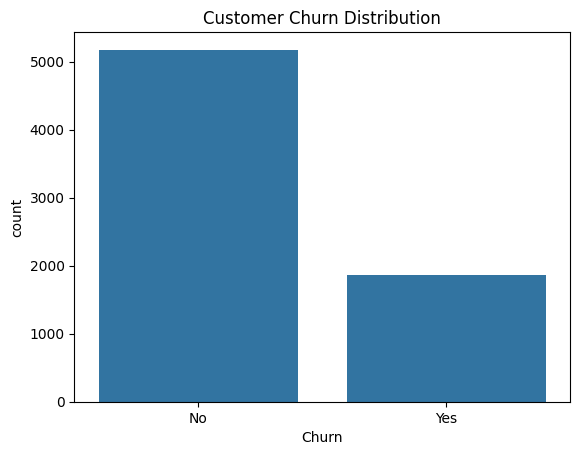

In [9]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

## 📝 Churn by Gender


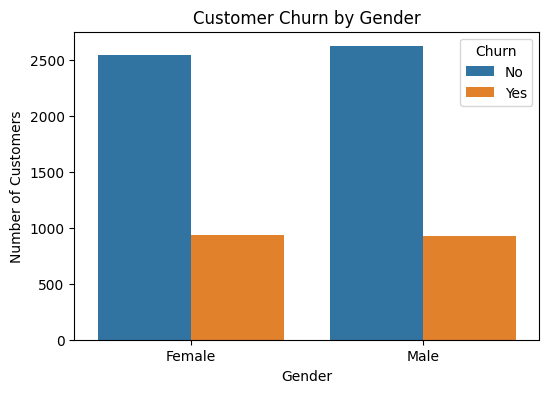

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## 📊 Churn by Contract Type

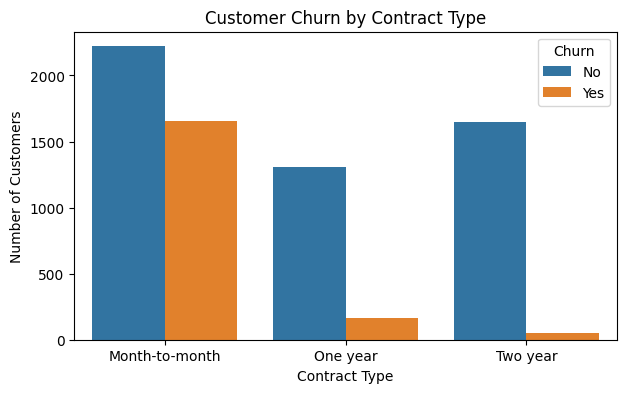

In [11]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

##  💰 Churn vs Monthly Charges


Average Monthly Charges:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


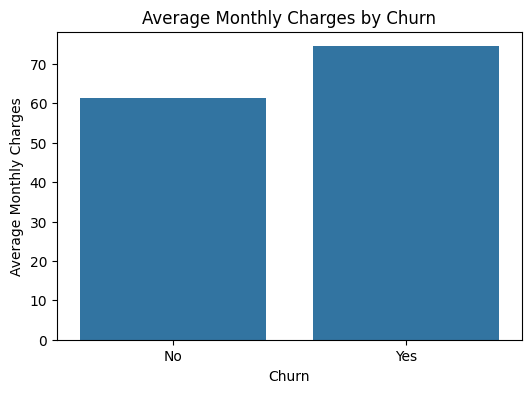

In [12]:
avg_charges = df.groupby("Churn")["MonthlyCharges"].mean()

print("Average Monthly Charges:")
print(avg_charges)

plt.figure(figsize=(6,4))

sns.barplot(x=avg_charges.index, y=avg_charges.values)

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")

plt.show()

##  🧹 Data Cleaning


In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## 🟢 Handle Missing Values

In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 🧩 Remove Unnecessary Columns


In [17]:
df.drop("customerID", axis=1, inplace=True)

In [18]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## 🔢 Encoding Target Variable


In [19]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [20]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## 🔢 Encoding Categorical Features


In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df.shape

(7032, 31)

## 🎯 Features and Target


In [23]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [24]:
print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


## ✂️ Train-Test Split


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


## ⚖️ Feature Scaling


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 🤖 Logistic Regression Model


In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
y_pred = model.predict(X_test)

## 📊 Model Evaluation


In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7874911158493249


## 🟢 Confusion Matrix

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[915 118]
 [181 193]]


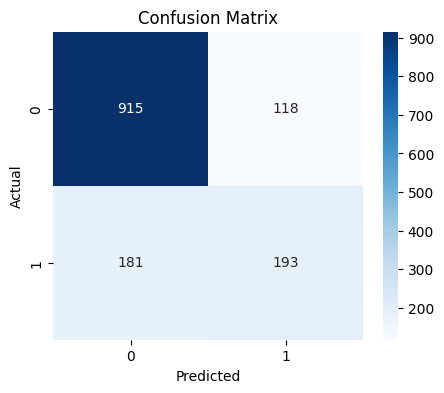

In [32]:
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 📑 Classification Report


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## 📈 ROC Curve


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8319235288940887


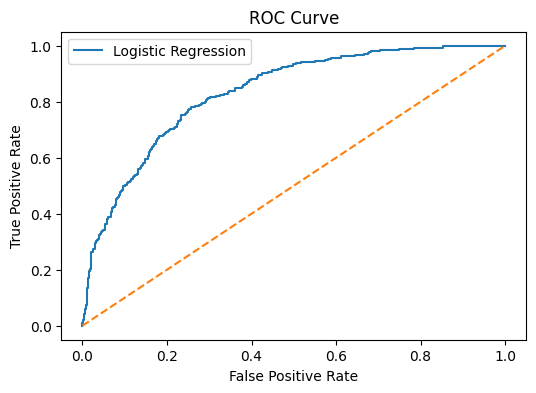

In [35]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Model Performance Evaluation

 * The model achieved an **AUC Score of 0.8319**, which indicates **good classification performance**.
 * The AUC (Area Under the ROC Curve) measures the ability of the model to distinguish between positive and negative classes.
 * An AUC score greater than **0.8** suggests that the model has strong discriminative power and performs well in separating the target classes.

## 🌳 Decision Tree Model

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
y_pred_dt = dt.predict(X_test)

## 📊 Model Evaluation


In [38]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.7256574271499645


## 🟢 Confusion Matrix

In [39]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[824 209]
 [177 197]]


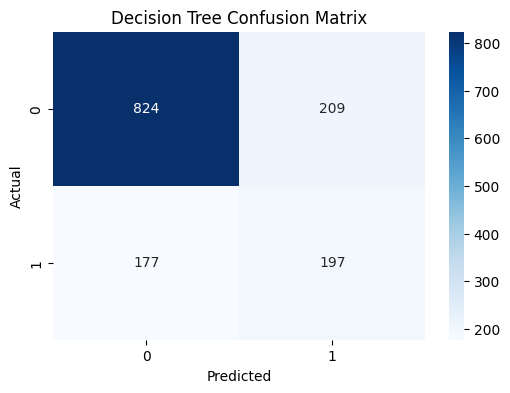

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 📑 Classification Report

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.49      0.53      0.51       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



## 📈 ROC Curve

In [42]:
from sklearn.metrics import roc_auc_score

y_prob_dt = dt.predict_proba(X_test)[:,1]

auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree AUC Score:", auc_dt)

Decision Tree AUC Score: 0.6638431752178122


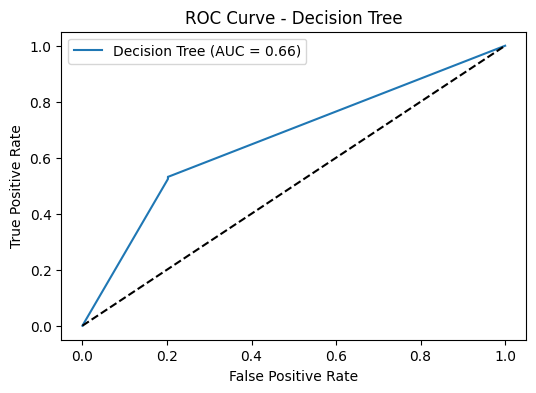

In [43]:
from sklearn.metrics import roc_curve

fpr_dt, tpr_dt, thresholds = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6,4))

plt.plot(fpr_dt, tpr_dt, label="Decision Tree (AUC = {:.2f})".format(auc_dt))

plt.plot([0,1],[0,1],'k--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.show()

## 🌲 Random Forest Model

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
y_pred_rf = rf.predict(X_test)

## 📊 Model Evaluation


In [46]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7846481876332623


## 🟢 Confusion Matrix

In [47]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[927 106]
 [197 177]]


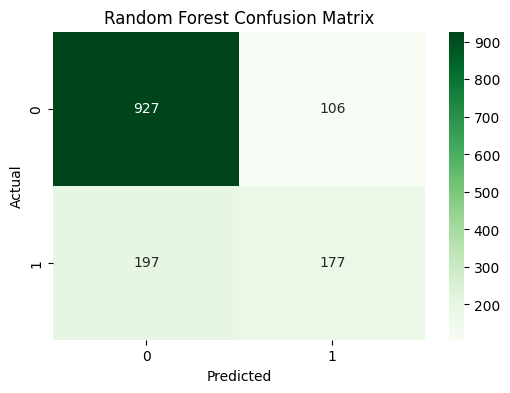

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 📑 Classification Report

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



## 📈 ROC Curve

In [50]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [51]:
from sklearn.metrics import roc_auc_score

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest AUC Score:", auc_rf)

Random Forest AUC Score: 0.8153358941041875


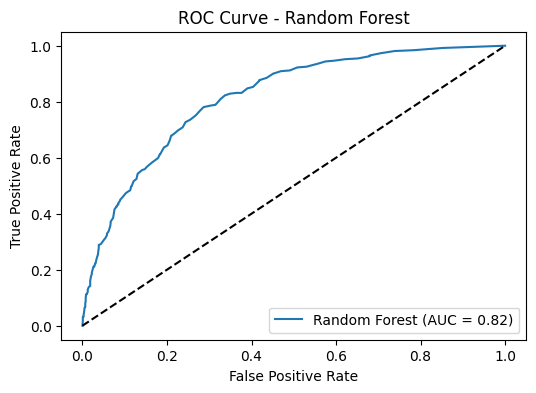

In [52]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))

plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = {:.2f})".format(auc_rf))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

## ⚡ XGBoost Model


In [53]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb.fit(X_train, y_train)

C:\Users\diyap\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [19:01:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [54]:
y_pred_xgb = xgb.predict(X_test)

## 📊 Model Evaluation


In [55]:
from sklearn.metrics import accuracy_score

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.7739872068230277


## 🟢 Confusion Matrix

In [56]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm_xgb)

Confusion Matrix:
[[903 130]
 [188 186]]


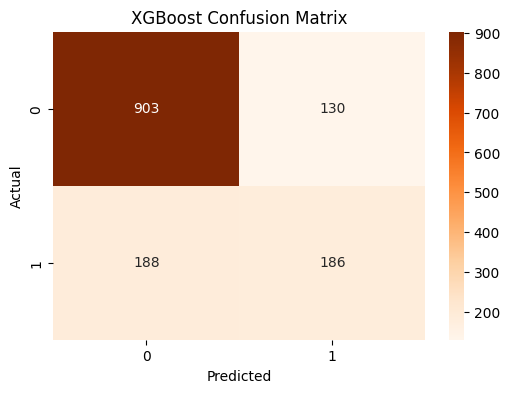

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 📑 Classification Report

In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



## 📈 ROC Curve

In [59]:
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [60]:
from sklearn.metrics import roc_auc_score

auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost AUC Score:", auc_xgb)

XGBoost AUC Score: 0.8108152880090697


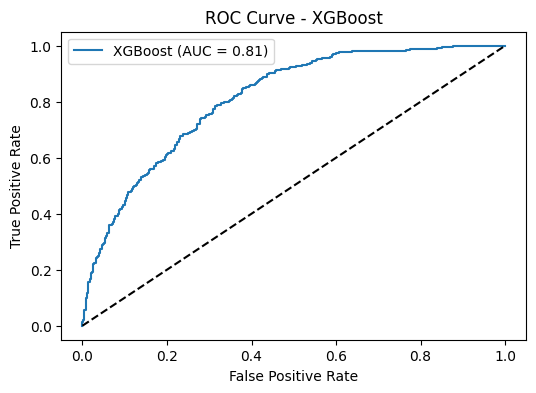

In [61]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_xgb, tpr_xgb, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,4))

plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = {:.2f})".format(auc_xgb))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

## 🔍 Feature Importance


In [62]:
X_train_df = pd.DataFrame(X_train)

importance_df = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
3,3,0.193409
2,2,0.169758
1,1,0.167572
10,10,0.039999
28,28,0.035016
13,13,0.028905
25,25,0.028618
4,4,0.026971
19,19,0.025829
26,26,0.025044


### 📊 Feature Importance Visualization


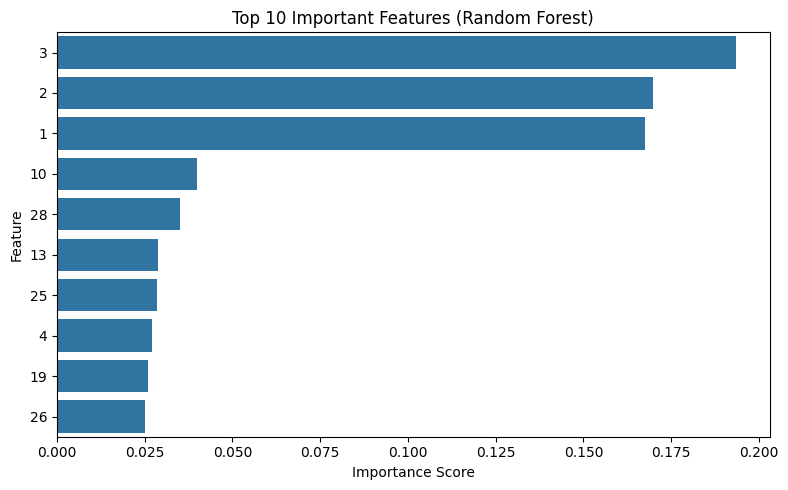

In [63]:
top_features = importance_df.head(10).reset_index(drop=True)

top_features["Feature"] = top_features["Feature"].astype(str)

plt.figure(figsize=(8,5))

sns.barplot(data=top_features, x="Importance", y="Feature")

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

## Model Comparison Graph

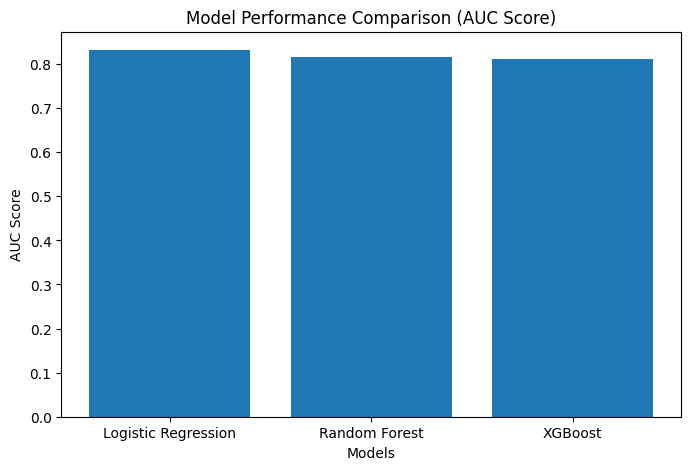

In [64]:
import matplotlib.pyplot as plt

# AUC scores of models
lr_auc = 0.8319
rf_auc = 0.8153
xgb_auc = 0.8108

models = ["Logistic Regression", "Random Forest", "XGBoost"]
scores = [lr_auc, rf_auc, xgb_auc]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.title("Model Performance Comparison (AUC Score)")
plt.xlabel("Models")
plt.ylabel("AUC Score")

plt.show()